# --- Notebook : Modèle SVM - Cas de Tests de Régression ---

In [15]:
# --- Notebook : Modèle Linéaire - Cas de Tests de Régression ---
import ctypes
import numpy as np
from numpy.ctypeslib import ndpointer
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [16]:
# === Chargement de la bibliothèque Rust compilée ===
lib = ctypes.CDLL("../target/release/mymodel.dll")

In [17]:
# === FFI declarations ===

lib.create_svm_rbf_classifier.argtypes = [
    ctypes.c_double,   # gamma
    ctypes.c_double,   # C
    ctypes.c_double,   # learning_rate
    ctypes.c_size_t    # epochs
]
lib.create_svm_rbf_classifier.restype = ctypes.c_void_p

lib.train_svm_rbf_classifier.argtypes = [
    ctypes.c_void_p,
    ndpointer(ctypes.c_double, flags="C_CONTIGUOUS"),  # X_flat
    ndpointer(ctypes.c_double, flags="C_CONTIGUOUS"),  # Y
    ctypes.c_size_t,                                   # n_samples
    ctypes.c_size_t                                    # n_features
]

lib.predict_svm_rbf_classifier.argtypes = [
    ctypes.c_void_p,
    ndpointer(ctypes.c_double, flags="C_CONTIGUOUS"),  # input vector
    ctypes.c_size_t                                    # n_features
]
lib.predict_svm_rbf_classifier.restype = ctypes.c_double


In [18]:
def run_svm_rbf_test(name, X, Y, lib, gamma=1.0, C=1.0, lr=0.01, epochs=1000):
    """
    Teste un classifieur SVM avec noyau RBF à partir de la bibliothèque Rust via FFI (sans n_support).
    """
    print(f"\n=== {name} ===")

    # Conversion des données
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    n_samples, n_features = X.shape
    X_flat = X.flatten()

    # Création du modèle
    model = lib.create_svm_rbf_classifier(gamma, C, lr, epochs)
    if not model:
        print(f"Erreur lors de la création du modèle SVM RBF pour {name}")
        return None

    # Entraînement
    lib.train_svm_rbf_classifier(model, X_flat, Y, n_samples, n_features)

    # Prédictions
    Y_pred = []
    for i in range(n_samples):
        x_input = X[i].astype(np.float64)
        pred = lib.predict_svm_rbf_classifier(model, x_input, n_features)
        Y_pred.append(int(pred))

    Y_pred = np.array(Y_pred)

    # Affichage des prédictions
    print("Exemples (prédiction vs vrai) :")
    for i in range(n_samples):
        print(f"  {X[i]} -> Prédit = {Y_pred[i]}, Vrai = {int(Y[i])}")

    return Y_pred


# Linear simple

In [20]:
def classif_test_linear_simple(lib, gamma=1.0, C=1.0, lr=0.05, epochs=1000):
    print("=== Classification Linéaire Simple avec SVM RBF ===")

    X = np.array([
        [1, 1], [2, 2], [3, 3],      # classe +1
        [1, 4], [2, 5], [3, 6]       # classe -1
    ], dtype=np.float64)

    Y = np.array([1, -1, 1, -1, 1, -1], dtype=np.float64)

    print("Données :")
    for i in range(len(X)):
        print(f"  {X[i]} -> {Y[i]}")

    # Prédictions
    Y_pred_rbf = run_svm_rbf_test("SVM RBF - Linear Simple", X, Y, lib, gamma, C, lr, epochs)

    # Affichage
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].scatter(X[Y == 1, 0], X[Y == 1, 1], color='blue', s=100, label='Classe +1')
    axes[0].scatter(X[Y == -1, 0], X[Y == -1, 1], color='red', s=100, label='Classe -1')
    axes[0].set_title("Données originales")
    axes[0].legend()
    axes[0].grid(True)

    ax = axes[1]
    for i in range(len(X)):
        color = 'blue' if Y_pred_rbf[i] == 1 else 'red'
        marker = 'o' if Y_pred_rbf[i] == Y[i] else 'x'
        ax.scatter(X[i, 0], X[i, 1], color=color, s=100, marker=marker)
    ax.set_title("Prédictions - SVM RBF")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


=== Classification Linéaire Simple avec SVM RBF ===
Données :
  [1. 1.] -> 1.0
  [2. 2.] -> -1.0
  [3. 3.] -> 1.0
  [1. 4.] -> -1.0
  [2. 5.] -> 1.0
  [3. 6.] -> -1.0

=== SVM RBF - Linear Simple ===
Exemples (prédiction vs vrai) :
  [1. 1.] -> Prédit = 1, Vrai = 1
  [2. 2.] -> Prédit = -1, Vrai = -1
  [3. 3.] -> Prédit = 1, Vrai = 1
  [1. 4.] -> Prédit = -1, Vrai = -1
  [2. 5.] -> Prédit = 1, Vrai = 1
  [3. 6.] -> Prédit = -1, Vrai = -1


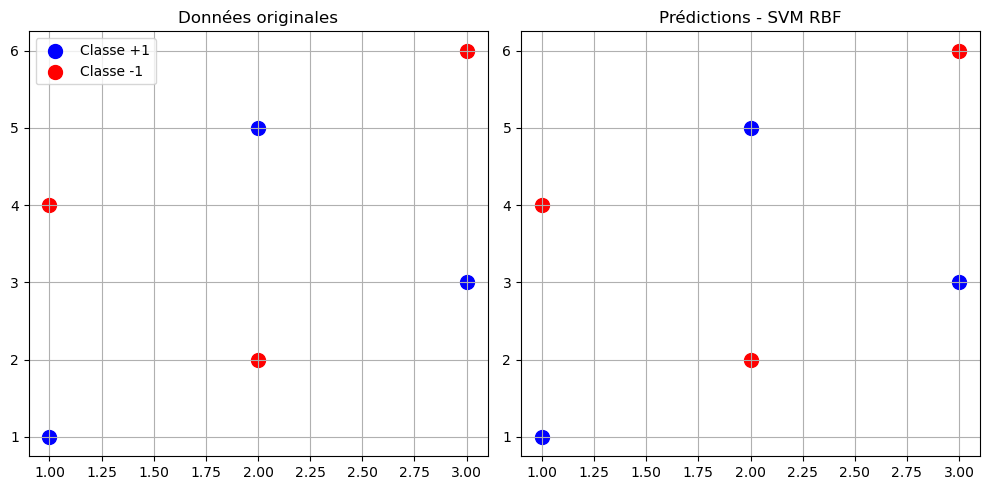

In [21]:
classif_test_linear_simple(lib, gamma=1.0, C=1.0, lr=0.05, epochs=1000)

# Linear Multiple

In [22]:
def classif_test_linear_multiple(lib, gamma=1.0, C=1.0, lr=0.05, epochs=1000):
    print("=== Classification Linéaire Multiple avec SVM RBF ===")

    X = np.array([
        [1, 1], [2, 2], [3, 3],
        [4, 4], [5, 5], [6, 6],
        [1, 6], [2, 7], [3, 8],
        [4, 9], [5, 10], [6, 11]
    ], dtype=np.float64)

    Y = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1], dtype=np.float64)

    print("Données :")
    for i in range(len(X)):
        print(f"  {X[i]} -> {Y[i]}")

    # Prédictions
    Y_pred_rbf = run_svm_rbf_test("SVM RBF - Linear Multiple", X, Y, lib, gamma, C, lr, epochs)

    # Affichage
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].scatter(X[Y == 1, 0], X[Y == 1, 1], color='blue', s=100, label='Classe +1')
    axes[0].scatter(X[Y == -1, 0], X[Y == -1, 1], color='red', s=100, label='Classe -1')
    axes[0].set_title("Données originales")
    axes[0].legend()
    axes[0].grid(True)

    ax = axes[1]
    for i in range(len(X)):
        color = 'blue' if Y_pred_rbf[i] == 1 else 'red'
        marker = 'o' if Y_pred_rbf[i] == Y[i] else 'x'
        ax.scatter(X[i, 0], X[i, 1], color=color, s=100, marker=marker)
    ax.set_title("Prédictions - SVM RBF")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


=== Classification Linéaire Multiple avec SVM RBF ===
Données :
  [1. 1.] -> 1.0
  [2. 2.] -> 1.0
  [3. 3.] -> 1.0
  [4. 4.] -> 1.0
  [5. 5.] -> 1.0
  [6. 6.] -> 1.0
  [1. 6.] -> -1.0
  [2. 7.] -> -1.0
  [3. 8.] -> -1.0
  [4. 9.] -> -1.0
  [ 5. 10.] -> -1.0
  [ 6. 11.] -> -1.0

=== SVM RBF - Linear Multiple ===
Exemples (prédiction vs vrai) :
  [1. 1.] -> Prédit = 1, Vrai = 1
  [2. 2.] -> Prédit = 1, Vrai = 1
  [3. 3.] -> Prédit = 1, Vrai = 1
  [4. 4.] -> Prédit = 1, Vrai = 1
  [5. 5.] -> Prédit = 1, Vrai = 1
  [6. 6.] -> Prédit = 1, Vrai = 1
  [1. 6.] -> Prédit = -1, Vrai = -1
  [2. 7.] -> Prédit = -1, Vrai = -1
  [3. 8.] -> Prédit = -1, Vrai = -1
  [4. 9.] -> Prédit = -1, Vrai = -1
  [ 5. 10.] -> Prédit = -1, Vrai = -1
  [ 6. 11.] -> Prédit = -1, Vrai = -1


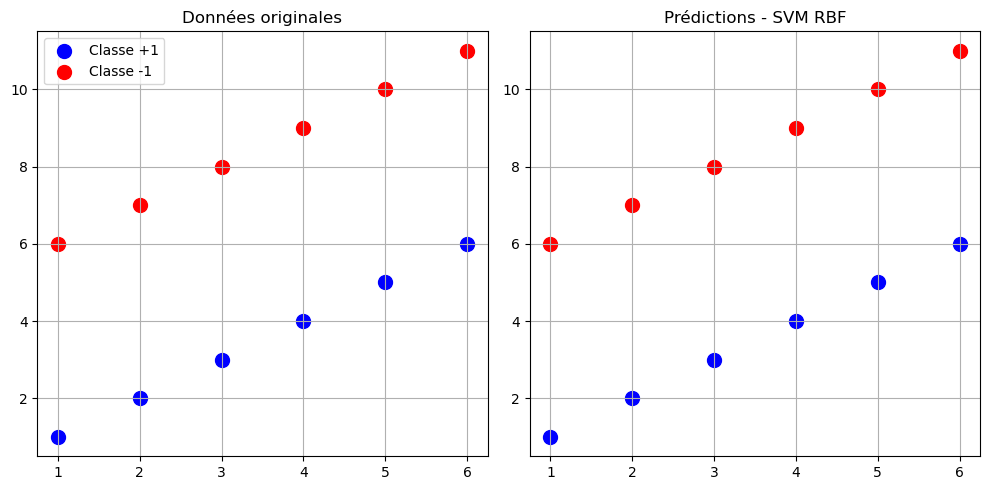

In [23]:
classif_test_linear_multiple(lib, gamma=1.0, C=1.0, lr=0.05, epochs=1000)

# XOR

In [11]:
def classif_test_3(lib, gamma=2.0, C=10.0, lr=0.05, epochs=2000):
    print("=== Classification XOR avec SVM RBF ===")

    X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=np.float64)
    Y = np.array([1, 1, -1, -1], dtype=np.float64)

    print("Données XOR:")
    for i in range(len(X)):
        print(f"  {X[i]} -> {Y[i]}")

    # Appel avec les paramètres modifiables (sans n_support)
    Y_pred_rbf = run_svm_rbf_test("SVM RBF - XOR", X, Y, lib, gamma, C, lr, epochs)

    # Affichage
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].scatter(X[Y == 1, 0], X[Y == 1, 1], color='blue', s=100, label='Classe +1')
    axes[0].scatter(X[Y == -1, 0], X[Y == -1, 1], color='red', s=100, label='Classe -1')
    axes[0].set_title("Données originales")
    axes[0].legend()
    axes[0].grid(True)

    ax = axes[1]
    for i in range(len(X)):
        color = 'blue' if Y_pred_rbf[i] == 1 else 'red'
        marker = 'o' if Y_pred_rbf[i] == Y[i] else 'x'
        ax.scatter(X[i, 0], X[i, 1], color=color, s=100, marker=marker)
    ax.set_title("Prédictions - SVM RBF")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
classif_test_3(lib, gamma=2.0, C=10.0, lr=0.05, epochs=2000)

#   Cross

In [13]:
def classif_test_cross(lib, gamma=1.0, C=1.0, lr=0.05, epochs=1000):
    print("=== Classification CROIX avec SVM RBF ===")

    X = np.array([
        [1, 0], [2, 0], [3, 0],
        [0, 1], [0, 2], [0, 3],
        [1, 1], [2, 2], [3, 3]
    ], dtype=np.float64)

    Y = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1], dtype=np.float64)

    print("Données :")
    for i in range(len(X)):
        print(f"  {X[i]} -> {Y[i]}")

    Y_pred_rbf = run_svm_rbf_test("SVM RBF - Cross", X, Y, lib, gamma, C, lr, epochs)

    # Affichage graphique
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].scatter(X[Y == 1, 0], X[Y == 1, 1], color='blue', s=100, label='Classe +1')
    axes[0].scatter(X[Y == -1, 0], X[Y == -1, 1], color='red', s=100, label='Classe -1')
    axes[0].set_title("Données originales")
    axes[0].legend()
    axes[0].grid(True)

    ax = axes[1]
    for i in range(len(X)):
        color = 'blue' if Y_pred_rbf[i] == 1 else 'red'
        marker = 'o' if Y_pred_rbf[i] == Y[i] else 'x'
        ax.scatter(X[i, 0], X[i, 1], color=color, s=100, marker=marker)
    ax.set_title("Prédictions - SVM RBF")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


=== Classification CROIX avec SVM RBF ===
Données :
  [1. 0.] -> 1.0
  [2. 0.] -> 1.0
  [3. 0.] -> 1.0
  [0. 1.] -> 1.0
  [0. 2.] -> 1.0
  [0. 3.] -> 1.0
  [1. 1.] -> -1.0
  [2. 2.] -> -1.0
  [3. 3.] -> -1.0

=== SVM RBF - Cross ===
Exemples (prédiction vs vrai) :
  [1. 0.] -> Prédit = 1, Vrai = 1
  [2. 0.] -> Prédit = 1, Vrai = 1
  [3. 0.] -> Prédit = 1, Vrai = 1
  [0. 1.] -> Prédit = 1, Vrai = 1
  [0. 2.] -> Prédit = 1, Vrai = 1
  [0. 3.] -> Prédit = 1, Vrai = 1
  [1. 1.] -> Prédit = 1, Vrai = -1
  [2. 2.] -> Prédit = -1, Vrai = -1
  [3. 3.] -> Prédit = -1, Vrai = -1


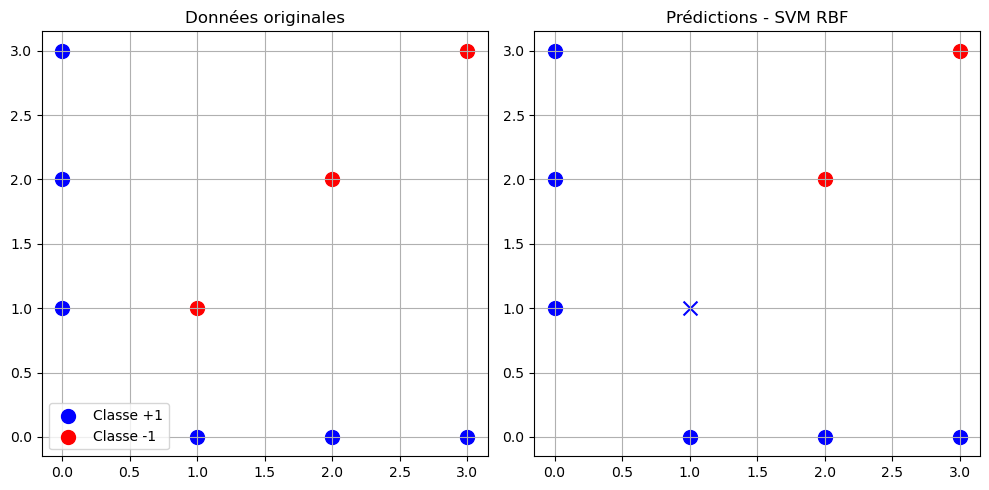

In [14]:
classif_test_cross(lib, gamma=1.0, C=1.0, lr=0.05, epochs=1000)
